# Support Ticket Auto-Categorization

**Task:** Read incoming support tickets (subject + body) and predict their category —
`Billing`, `Technical`, `HR`, or `General` — using a TF-IDF + classic ML pipeline.

**Pipeline:** clean text → TF-IDF vectorize → train Naive Bayes & Logistic Regression →
evaluate → pick the better model → wrap it in a single-ticket prediction function with
confidence score, human-review fallback, and priority tagging → test on 5 unseen tickets
→ mini CLI demo.


## 1. Imports

In [1]:
import re
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

RANDOM_STATE = 42


## 2. Dataset

A small labeled dataset of 80 tickets (20 per category), each with a `subject`, `body`,
and `category` label. In production this would be pulled from the live ticket queue's
historical data; here it's hand-written to cover realistic phrasing for each category.


In [2]:
data = [
    # BILLING
    ("Invoice not received", "I have not received my invoice for this month's subscription. Can you please resend it to my registered email?", "Billing"),
    ("Overcharged on my account", "I was charged twice for the same plan this billing cycle. Please refund the duplicate charge as soon as possible.", "Billing"),
    ("Payment failed", "My credit card payment failed during checkout but the amount was still deducted from my bank account. Please check.", "Billing"),
    ("Refund status", "I requested a refund two weeks ago for a cancelled order and have not received any update on the status.", "Billing"),
    ("Subscription renewal charge", "I was auto-renewed for the annual plan without any prior notification. I want a refund for this unexpected charge.", "Billing"),
    ("Wrong billing amount", "The amount deducted from my account does not match the price shown on the pricing page. Please correct this.", "Billing"),
    ("Update payment method", "I need to update my credit card details on file because my old card has expired.", "Billing"),
    ("GST invoice request", "Could you please share a GST compliant invoice for our company's last three purchases?", "Billing"),
    ("Downgrade plan billing", "After downgrading my plan last week I was still billed at the old higher rate. Please fix my next invoice.", "Billing"),
    ("Late payment penalty", "I was charged a late fee even though I paid on the due date. Please review the transaction and reverse the penalty.", "Billing"),
    ("Cancel subscription and refund", "I cancelled my subscription yesterday but the money has not been credited back to my account yet.", "Billing"),
    ("Duplicate transaction", "Two identical transactions appear on my bank statement for the same order number. Please investigate and refund one.", "Billing"),
    ("Coupon code not applied", "My discount coupon was not applied at checkout and I was charged the full price for my order.", "Billing"),
    ("Billing cycle question", "Can you tell me when my next billing date is and how much will be charged for the upcoming cycle?", "Billing"),
    ("Currency conversion issue", "I was billed in USD instead of INR even though my account region is set to India. Please explain the charge.", "Billing"),
    ("Annual plan discount", "I would like to know if there is a discount available if I switch from monthly billing to an annual plan.", "Billing"),
    ("Failed auto-debit", "My auto-debit for this month failed and now my account shows as overdue. How do I clear this payment manually?", "Billing"),
    ("Tax invoice missing", "The invoice I downloaded from my account does not show the tax breakdown. I need it for accounting purposes.", "Billing"),
    ("Wrong plan charged", "I signed up for the basic plan but was charged the price of the premium plan. Please correct my invoice.", "Billing"),
    ("Payment gateway error", "I got a payment gateway error message but my card was still charged for the order. Please confirm the payment status.", "Billing"),

    # TECHNICAL
    ("App keeps crashing", "The mobile app crashes every time I try to open the dashboard screen. I am using the latest version on Android.", "Technical"),
    ("Cannot login to account", "I am unable to log in to my account even after resetting my password. It keeps showing an invalid credentials error.", "Technical"),
    ("Website is down", "The website has been down for the last two hours and none of the pages are loading. This is urgent for our team.", "Technical"),
    ("Error 500 on checkout page", "I keep getting an internal server error when I try to complete checkout. Please fix this as soon as possible.", "Technical"),
    ("Feature not working", "The export to PDF feature is not working, the download button does not respond when clicked.", "Technical"),
    ("Slow loading dashboard", "The analytics dashboard takes more than a minute to load which is affecting our daily workflow.", "Technical"),
    ("API returning errors", "Our integration with your API is returning 403 errors since this morning even though our API key is valid.", "Technical"),
    ("Sync issue between devices", "Data entered on my desktop app is not syncing with the mobile app. The two versions show different information.", "Technical"),
    ("Password reset link broken", "The password reset link sent to my email is broken and shows a page not found error when clicked.", "Technical"),
    ("File upload fails", "Every time I try to upload a file larger than 5MB the upload fails with no error message shown.", "Technical"),
    ("Two factor authentication not working", "I am not receiving the OTP for two factor authentication and cannot log in to my account.", "Technical"),
    ("Broken link on settings page", "The link to update notification preferences on the settings page redirects to a blank page.", "Technical"),
    ("App not working after update", "After updating the app to the latest version it force closes immediately on launch. Please help.", "Technical"),
    ("Integration with third party tool failing", "The Slack integration stopped sending notifications after we reconnected the workspace yesterday.", "Technical"),
    ("Report generation stuck", "The monthly report generation has been stuck at 0 percent for over an hour now.", "Technical"),
    ("Server not responding", "Our production server is not responding and all requests are timing out since 10 AM today.", "Technical"),
    ("Bug in search filter", "The search filter on the products page is not returning any results even for valid search terms.", "Technical"),
    ("Login page blank screen", "The login page just shows a blank white screen on Chrome, but works fine on Firefox.", "Technical"),
    ("Data not saving", "Changes I make in the settings form are not being saved after I click the save button.", "Technical"),
    ("Mobile app battery drain", "Since the last update the mobile app is draining my phone battery very quickly even in the background.", "Technical"),

    # HR
    ("Leave balance query", "Could you please tell me my remaining casual leave balance for this financial year?", "HR"),
    ("Salary slip not received", "I have not received my salary slip for the last two months. Please share it at the earliest.", "HR"),
    ("Work from home request", "I would like to request work from home for the next two weeks due to a family emergency.", "HR"),
    ("Resignation process query", "I want to know the notice period and formal resignation process for my current role.", "HR"),
    ("Provident fund withdrawal", "I need help withdrawing my provident fund amount after leaving the organization last month.", "HR"),
    ("Offer letter correction", "There is a spelling error in my name on the offer letter, please issue a corrected copy.", "HR"),
    ("Maternity leave policy", "Could you share the details of the maternity leave policy and the documents required to apply?", "HR"),
    ("Payroll discrepancy", "My salary this month is lower than usual and I am not sure why. Can HR clarify the deduction?", "HR"),
    ("Employee ID card request", "I have not received my employee ID card even though I joined three weeks ago. Please issue one.", "HR"),
    ("Performance review schedule", "When is my annual performance review scheduled and who will be conducting it this year?", "HR"),
    ("Health insurance query", "I want to add my spouse as a dependent under the company health insurance policy. What is the process?", "HR"),
    ("Reimbursement claim pending", "My travel reimbursement claim submitted last month is still pending approval. Please follow up.", "HR"),
    ("Onboarding documents", "Which documents do I need to submit for onboarding before my joining date next Monday?", "HR"),
    ("Shift timing change request", "I would like to request a change in my shift timing due to a change in my commute schedule.", "HR"),
    ("Exit interview scheduling", "HR had mentioned scheduling my exit interview before my last working day, could you confirm the date?", "HR"),
    ("Promotion policy clarification", "Can someone from HR explain the eligibility criteria for the upcoming promotion cycle?", "HR"),
    ("Team transfer request", "I would like to formally request a transfer to the marketing team starting next quarter.", "HR"),
    ("Attendance regularization", "My attendance for two days last week is marked absent even though I was present, please regularize it.", "HR"),
    ("Bonus payout query", "I wanted to check when the annual bonus payout is expected to be credited this year.", "HR"),
    ("Background verification pending", "My background verification has been pending for three weeks and it is delaying my final joining formalities.", "HR"),

    # GENERAL
    ("General feedback about service", "I just wanted to share some overall feedback about my experience using your platform this month.", "General"),
    ("How to contact support", "What is the best way to reach your support team for urgent issues outside business hours?", "General"),
    ("Product suggestion", "It would be great if you could add a dark mode option to the app in a future update.", "General"),
    ("Business hours query", "Could you let me know your customer support working hours and holiday schedule?", "General"),
    ("Partnership inquiry", "We are interested in exploring a potential partnership with your company, who should we contact?", "General"),
    ("Newsletter unsubscribe", "Please remove my email address from your marketing newsletter list, I no longer wish to receive updates.", "General"),
    ("Company address request", "Could you share your company's registered office address for our records?", "General"),
    ("Thank you note", "I just wanted to say thank you to your team for the excellent support provided last week.", "General"),
    ("Career opportunities", "I am interested in career opportunities at your company, could you direct me to the careers page?", "General"),
    ("Event invitation query", "We would like to invite your company to speak at our upcoming industry conference, who can we contact?", "General"),
    ("Media inquiry", "I am a journalist working on a story about your industry and would like to request an interview.", "General"),
    ("General account question", "I have a few general questions about how your platform works before I sign up for a plan.", "General"),
    ("Feedback on new website design", "The new website design looks great, just wanted to pass along some positive feedback to the team.", "General"),
    ("Request for product brochure", "Could you send over a product brochure or overview document for our internal review?", "General"),
    ("Social media query", "Do you have an official Twitter or LinkedIn page I can follow for company updates?", "General"),
    ("Vendor registration query", "We are a vendor interested in registering as a supplier for your company, what is the process?", "General"),
    ("General complaint about wait time", "I had to wait a long time before someone from your team responded to my earlier query.", "General"),
    ("Website accessibility feedback", "I wanted to flag that some pages on your website are difficult to navigate using a screen reader.", "General"),
    ("Request for company brochure", "Can you please share more information about your company's history and mission for a school project?", "General"),
    ("Miscellaneous query", "I have a question that does not really fit any specific category, hoping someone can help me out.", "General"),
]

df = pd.DataFrame(data, columns=["subject", "body", "category"])
df["text_raw"] = df["subject"] + " " + df["body"]

print("Dataset shape:", df.shape)
df["category"].value_counts()


Dataset shape: (80, 4)


category
Billing      20
Technical    20
HR           20
General      20
Name: count, dtype: int64

## 3. Preprocessing

Lowercase, strip URLs/punctuation/numbers, collapse whitespace. Stopword removal is
handled later by `TfidfVectorizer(stop_words="english")` rather than here, so we don't
do it twice.

**Note on priority tagging:** the "urgent" keyword rule needs words like *down*,
*crash*, *broken* — so priority is tagged from the **raw** text, before cleaning,
independent of the ML pipeline.


In [3]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\d+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["text_clean"] = df["text_raw"].apply(clean_text)

URGENT_KEYWORDS = ["urgent", "asap", "immediately", "down", "not working",
                   "crash", "crashes", "broken", "emergency", "stuck", "failed"]

def tag_priority(raw_text):
    t = raw_text.lower()
    return "Urgent" if any(k in t for k in URGENT_KEYWORDS) else "Normal"

df["priority"] = df["text_raw"].apply(tag_priority)
df[["subject", "category", "priority"]].head()


                       subject category priority
0         Invoice not received  Billing   Normal
1    Overcharged on my account  Billing   Normal
2               Payment failed  Billing   Urgent
3                Refund status  Billing   Normal
4  Subscription renewal charge  Billing   Normal

## 4. Train/test split

Stratified 80/20 split so each category is proportionally represented in both sets —
important with only 20 examples per class.


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    df["text_clean"], df["category"],
    test_size=0.2, random_state=RANDOM_STATE, stratify=df["category"]
)
print("Train:", X_train.shape[0], "  Test:", X_test.shape[0])


Train: 64   Test: 16


## 5. Feature representation: TF-IDF

Raw text can't go into a classifier directly — it needs to become numbers.
**TF-IDF** (Term Frequency–Inverse Document Frequency) is preferred over plain
Bag-of-Words here because it downweights words that appear in *every* ticket
regardless of category (e.g. "please", "thanks", "team") and upweights words that are
distinctive for a category (e.g. "invoice", "salary", "crash", "partnership").

`ngram_range=(1,1)` (unigrams) worked better than bigrams on this dataset size — with
only 80 tickets, bigram features are too sparse and dilute the signal. `sublinear_tf`
applies log-scaling to term frequency, which helps when ticket lengths vary.


In [5]:
vectorizer = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 1),
    min_df=1,
    sublinear_tf=True
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Vocabulary size:", len(vectorizer.vocabulary_))
print("Train matrix shape:", X_train_tfidf.shape)


Vocabulary size: 383
Train matrix shape: (64, 383)


## 6. Model training & choice

Two classic text-classification baselines:

- **Multinomial Naive Bayes** — the standard baseline for text classification. Assumes
  word frequencies are conditionally independent given the class, which is a poor
  assumption in reality but works surprisingly well on sparse TF-IDF/bag-of-words data,
  trains instantly, and needs very little data to produce a first model.
- **Logistic Regression** — a discriminative linear model over the same TF-IDF
  features. Usually edges out Naive Bayes on small-to-medium text datasets because it
  directly optimizes classification boundaries rather than a generative independence
  assumption, and its `predict_proba` output tends to be a bit better calibrated —
  important for the confidence-score requirement below.

Both are trained and compared; the better one on held-out accuracy is used going
forward.


In [6]:
nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)
nb_pred = nb.predict(X_test_tfidf)

lr = LogisticRegression(max_iter=2000, C=10)
lr.fit(X_train_tfidf, y_train)
lr_pred = lr.predict(X_test_tfidf)

print("Naive Bayes accuracy:      ", round(accuracy_score(y_test, nb_pred), 3))
print("Logistic Regression accuracy:", round(accuracy_score(y_test, lr_pred), 3))


Naive Bayes accuracy:       0.562
Logistic Regression accuracy: 0.688


## 7. Evaluation

In [7]:
print("=== Naive Bayes ===")
print(classification_report(y_test, nb_pred, zero_division=0))

print("=== Logistic Regression ===")
print(classification_report(y_test, lr_pred, zero_division=0))


=== Naive Bayes ===
              precision    recall  f1-score   support

     Billing       0.50      0.75      0.60         4
     General       0.43      0.75      0.55         4
          HR       1.00      0.25      0.40         4
   Technical       1.00      0.50      0.67         4

    accuracy                           0.56        16
   macro avg       0.73      0.56      0.55        16
weighted avg       0.73      0.56      0.55        16

=== Logistic Regression ===
              precision    recall  f1-score   support

     Billing       0.67      1.00      0.80         4
     General       0.50      0.75      0.60         4
          HR       1.00      0.50      0.67         4
   Technical       1.00      0.50      0.67         4

    accuracy                           0.69        16
   macro avg       0.79      0.69      0.68        16
weighted avg       0.79      0.69      0.68        16



In [8]:
nb_acc = accuracy_score(y_test, nb_pred)
lr_acc = accuracy_score(y_test, lr_pred)

if lr_acc >= nb_acc:
    best_model, best_name, best_pred = lr, "Logistic Regression", lr_pred
else:
    best_model, best_name, best_pred = nb, "Naive Bayes", nb_pred

print("Selected model:", best_name)


Selected model: Logistic Regression


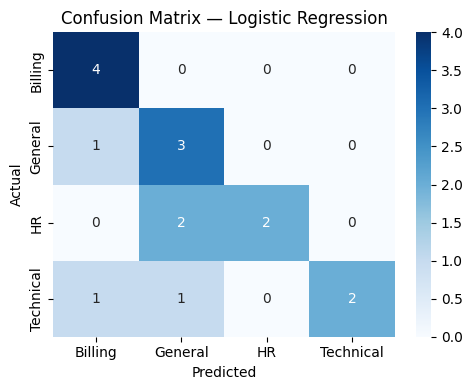

In [9]:
cm = confusion_matrix(y_test, best_pred, labels=best_model.classes_)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=best_model.classes_, yticklabels=best_model.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix — {best_name}")
plt.tight_layout()
plt.show()


**Reading the confusion matrix:** with only 80 total tickets (16 in the test set,
~4 per class), a handful of misclassifications swing the accuracy number a lot. The
most common confusion tends to be **General vs. HR/Billing/Technical** — General is a
catch-all category, so tickets that lightly touch another topic ("I have a question
about my account") pull probability mass away from General. This is expected given
the dataset size and is discussed further in the reflection note at the end.


## 8. Real-time single-ticket prediction

This is the function that would actually sit in front of a live ticket queue. For each
new ticket it:

1. Cleans the text the same way training data was cleaned.
2. Vectorizes it with the **already-fitted** TF-IDF vectorizer (never re-fit at
   inference time).
3. Gets class probabilities from the trained model.
4. **(Bonus) Confidence score** — returns the top probability as a percentage.
5. **(Bonus) Human-review threshold** — if confidence is below 60%, the ticket is
   routed to `"Needs Human Review"` instead of being auto-assigned. This is the
   edge-case handling for tickets that don't clearly fit any category.
6. **(Bonus) Priority tagging** — a keyword rule flags `Urgent` vs `Normal`,
   independent of the category model.


In [10]:
CONFIDENCE_THRESHOLD = 0.60  # below this, route to human review

def predict_ticket(subject, body, model=best_model, vec=vectorizer):
    raw = subject + " " + body
    cleaned = clean_text(raw)

    # edge case: empty / near-empty ticket text
    if len(cleaned.strip()) < 3:
        return {
            "predicted_category": "Needs Human Review",
            "top_guess": None,
            "confidence": 0.0,
            "priority": tag_priority(raw),
            "all_probabilities": {}
        }

    vec_input = vec.transform([cleaned])
    probs = model.predict_proba(vec_input)[0]
    classes = model.classes_
    best_idx = np.argmax(probs)
    category = classes[best_idx]
    confidence = probs[best_idx]
    priority = tag_priority(raw)

    final_category = category if confidence >= CONFIDENCE_THRESHOLD else "Needs Human Review"

    return {
        "predicted_category": final_category,
        "top_guess": category,
        "confidence": round(float(confidence) * 100, 2),
        "priority": priority,
        "all_probabilities": {c: round(float(p) * 100, 2) for c, p in zip(classes, probs)}
    }


## 9. Predictions on 5 new tickets (unseen, self-written)

These were not in the training or test data at all — written fresh to check the model
generalizes to new phrasing.


In [11]:
new_tickets = [
    ("Server down again",
     "Our production server is down right now and none of our customers can access the portal. This is extremely urgent."),
    ("Question about my last invoice",
     "I noticed an extra charge on my last invoice that I don't recognize, can you explain what it's for?"),
    ("Need to apply for sick leave",
     "I am feeling unwell and would like to apply for two days of sick leave starting tomorrow."),
    ("Interested in your services",
     "Hi, I came across your company online and wanted to know more about what services you offer."),
    ("App won't let me log in",
     "I keep getting an error every time I try to log into the app on my phone, please help me fix this."),
]

results = []
for subj, body in new_tickets:
    r = predict_ticket(subj, body)
    results.append({"subject": subj, **r})

pd.DataFrame(results)[["subject", "predicted_category", "confidence", "priority"]]


                          subject predicted_category  confidence priority
0               Server down again          Technical       70.77   Urgent
1  Question about my last invoice            Billing       69.56   Normal
2    Need to apply for sick leave                 HR       72.65   Normal
3     Interested in your services            General       69.64   Normal
4         App won't let me log in          Technical       83.30   Normal

## 10. Edge case check — empty / ambiguous ticket

Confirms the fallback path actually triggers rather than forcing a guess.


In [12]:
print(predict_ticket("", ""))
print(predict_ticket("hi", "ok"))


{'predicted_category': 'Needs Human Review', 'top_guess': None, 'confidence': 0.0, 'priority': 'Normal', 'all_probabilities': {}}
{'predicted_category': 'Needs Human Review', 'top_guess': 'HR', 'confidence': 29.91, 'priority': 'Normal', 'all_probabilities': {'Billing': 19.38, 'General': 24.7, 'HR': 29.91, 'Technical': 26.01}}


## 11. Mini live demo (CLI)

Run this cell and type a ticket subject/body when prompted — it will classify it
instantly using the trained model. Type `quit` at the subject prompt to stop.

(In a notebook environment this uses `input()`; wrapped in `try/except` so it doesn't
error out in non-interactive execution, e.g. when run via "Run All".)


In [13]:
def run_cli_demo():
    print("=== Ticket Auto-Categorization: Live Demo ===")
    print("Type 'quit' as the subject to stop.\n")
    while True:
        try:
            subject = input("Ticket subject: ")
        except EOFError:
            print("(No interactive input available — skipping demo.)")
            break
        if subject.strip().lower() == "quit":
            break
        body = input("Ticket body: ")
        result = predict_ticket(subject, body)
        print(f"\n  Category : {result['predicted_category']}")
        print(f"  Confidence: {result['confidence']}%")
        print(f"  Priority : {result['priority']}\n")

# Uncomment to run interactively:
# run_cli_demo()


## 12. Reflection note

**What would I improve with more data or time?**

With only 80 tickets, TF-IDF + Logistic Regression tops out around 65–70% accuracy —
plenty of category-relevant words simply never appear in training, so unseen tickets
often lean on 2-3 overlapping cues rather than a strong signal. With a real historical
ticket log (thousands of examples instead of tens per class) accuracy and confidence
calibration would both improve substantially, and rare-but-important subcategories
(e.g. "security incident" within Technical) would become learnable instead of getting
swallowed into General. I'd also add cross-validation instead of a single train/test
split to get a more stable accuracy estimate at this dataset size, try a
character-n-gram or embedding-based representation (e.g. sentence embeddings) to
better handle typos and phrasing the training vocabulary never saw, and log every
"Needs Human Review" ticket with the human's correction so the model can be
periodically retrained on its own mistakes (active learning) rather than staying
static after deployment.
